# Short Burst Analysis
Reference: @author: erv2, and all authors of https://github.com/vrdi/shortbursts-gingles/blob/

## Initialization

In [1]:
import numpy as np
import pickle
from gerrychain import Graph, Partition
from gerrychain.updaters import Tally, cut_edges
from gingleator import Gingleator

In [2]:
score_functs = {0: None, 
                1: Gingleator.reward_partial_dist, 
                2: Gingleator.reward_next_highest_close,
                3: Gingleator.penalize_maximum_over,
                4: Gingleator.penalize_avg_over}

In [3]:
graph = Graph.from_file("../data/AZ_shapefile/AZ.shp")

In [5]:
my_updaters = {"population" : Tally("TOTPOP", alias="population"),
               "VAP": Tally("VAP"),
               "AMINVAP": Tally("AMINVAP"),
               "cut_edges": cut_edges}

In [6]:
init_partition = Partition(graph, assignment="SEND", updaters=my_updaters)

In [7]:
# define short burst run function
def sb_run(burst_len, iters, pop_col, score_funct, eps, min_pop_col, threshold):
    gingles = Gingleator(init_partition, pop_col=POP_COL,
                     threshold=THRESHOLD, score_funct=SCORE_FUNCT, epsilon=EPS,
                     minority_perc_col="{}_perc".format(MIN_POP_COL))

    gingles.init_minority_perc_col(MIN_POP_COL, "VAP", "{}_perc".format(MIN_POP_COL))

    num_bursts = int(ITERS/BURST_LEN)
    
    sb_obs = gingles.short_burst_run(num_bursts=num_bursts, num_steps=BURST_LEN, maximize=True, verbose=False)

    return {"VAP": sb_obs[0][0]["VAP"], "AMINVAP": sb_obs[0][0]["AMINVAP"]}

In [9]:
# Global (fixed) parameters
POP_COL = "TOTPOP"
MIN_POP_COL = 'AMINVAP'
EPS = 0.1
ITERS = 10000
SCORE_FUNCT = score_functs[1]

## 1st run

In [10]:
# Parameters for the short burst
BURST_LEN = 10 # 10, 50
THRESHOLD = 0.5 # 5, 10, 20, 30

In [11]:
sb_1 = sb_run(burst_len=BURST_LEN, iters=ITERS, pop_col=POP_COL, score_funct=SCORE_FUNCT, eps=EPS, min_pop_col=MIN_POP_COL, threshold=THRESHOLD)
sb_1

{'VAP': {6: 206488,
  19: 192855,
  21: 159928,
  7: 200429,
  30: 182250,
  16: 200565,
  17: 174861,
  23: 169256,
  1: 187461,
  25: 197196,
  15: 183184,
  10: 195968,
  9: 187872,
  3: 188062,
  14: 201820,
  12: 156432,
  13: 186759,
  8: 185011,
  5: 164687,
  4: 185368,
  2: 186756,
  26: 174465,
  27: 194464,
  28: 186018,
  11: 183649,
  22: 187429,
  29: 191077,
  24: 171987,
  18: 191414,
  20: 168265},
 'AMINVAP': {6: 6564,
  19: 8630,
  21: 81089,
  7: 4971,
  30: 9215,
  16: 10878,
  17: 6065,
  23: 39634,
  1: 5369,
  25: 3079,
  15: 13384,
  10: 6894,
  9: 8252,
  3: 12189,
  14: 8235,
  12: 6513,
  13: 5264,
  8: 4226,
  5: 3477,
  4: 6945,
  2: 8998,
  26: 5631,
  27: 4180,
  28: 5159,
  11: 8874,
  22: 10158,
  29: 5442,
  24: 4427,
  18: 8474,
  20: 7014}}

In [19]:
number_districts = {90: 0, 80: 0, 70: 0, 60: 0, 50: 0, 40: 0, 30: 0, 20: 0, 10: 0}
for key in sb_1['VAP'].keys():
    percent = sb_1['AMINVAP'][key] / sb_1['VAP'][key]
    for k in number_districts.keys():
        if percent >= k / 100:
            number_districts[k] += 1
number_districts

{90: 0, 80: 0, 70: 0, 60: 0, 50: 1, 40: 1, 30: 1, 20: 2, 10: 2}

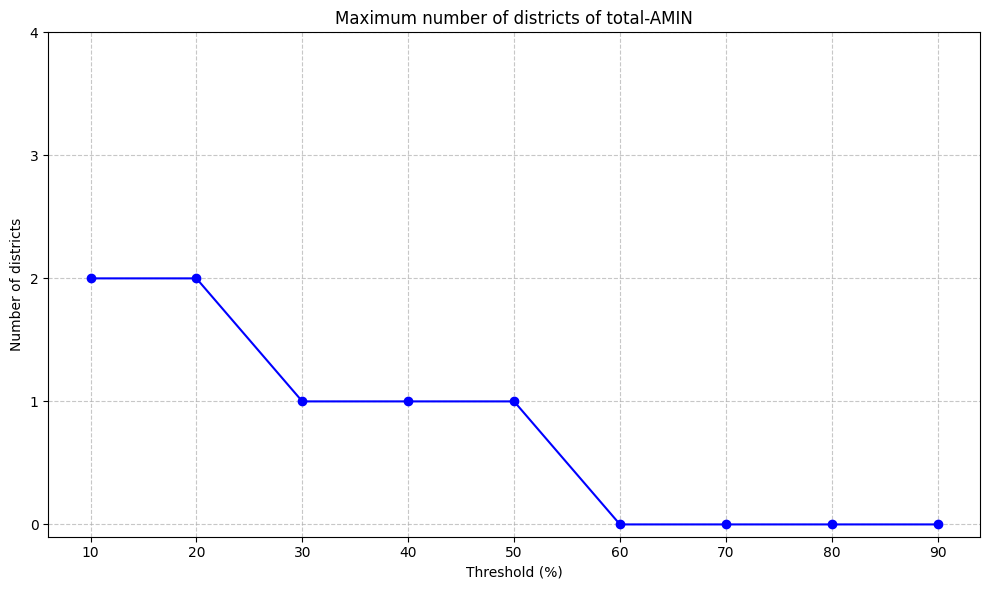

In [20]:
import matplotlib.pyplot as plt

# Extract keys and values
x = list(number_districts.keys())
y = list(number_districts.values())

# Create the plot
plt.figure(figsize=(10, 6))
plt.plot(x, y, marker='o', linestyle='-', color='b')

# Add labels and title
plt.ylabel('Number of districts')
plt.xlabel('Threshold (%)')
plt.title('Maximum number of districts of total-AMIN')

# Add grid lines
plt.grid(True, linestyle='--', alpha=0.7)
plt.yticks([i for i in range(5)])

# Show the plot
plt.tight_layout()
plt.savefig("../data/AZ_sb/AZ_sb_1.png")
plt.show()
plt.close()